In [1]:
# =============================================================================
# Cell 1: Imports & Setup
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

plt.style.use('seaborn-v0_8')
%matplotlib inline

DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(exist_ok=True)

## 1. Imports & Setup

# Notebook Structure Overview
This notebook follows a standard data science workflow: imports, data loading, diagnostics, merging, EDA, feature engineering, modeling, and evaluation.

In [2]:
# Load + Smart ID detection
profiles = pd.read_csv(DATA_DIR / "customer_social_profiles.csv")
transactions = pd.read_csv(DATA_DIR / "customer_transactions.csv")

print("Profiles shape:", profiles.shape)
print("Transactions shape:", transactions.shape)

print("\nProfiles columns:", profiles.columns.tolist())
print("Transactions columns:", transactions.columns.tolist())

# Standardize customer ID for merging
profiles['customer_id'] = profiles['customer_id_new'].str.replace('A','',regex=False)
transactions['customer_id'] = transactions['customer_id_legacy'].astype(str)

# Try to auto-detect possible merge keys
possible_keys = ['customer_id_new', 'customer_id_legacy']
merge_key_candidates = [col for col in profiles.columns if col.lower() in [k.lower() for k in possible_keys]]
merge_key_candidates += [col for col in transactions.columns if col.lower() in [k.lower() for k in possible_keys]]

print("\nPossible merge key candidates:", set(merge_key_candidates))

# Set the correct merge key based on your data
merge_key_profiles = 'customer_id'
merge_key_transactions = 'customer_id'

# Show overlapping IDs if possible
if merge_key_profiles in profiles.columns and merge_key_transactions in transactions.columns:
    common_ids = set(profiles[merge_key_profiles]) & set(transactions[merge_key_transactions])
    print(f"\nCommon customer IDs:", len(common_ids))
    print("Sample common IDs:", list(common_ids)[:5] if common_ids else "NONE – no overlap!")
else:
    print(f"\nWarning: Merge keys not found in both DataFrames!")

Profiles shape: (155, 5)
Transactions shape: (150, 6)

Profiles columns: ['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment']
Transactions columns: ['customer_id_legacy', 'transaction_id', 'purchase_amount', 'purchase_date', 'product_category', 'customer_rating']

Possible merge key candidates: {'customer_id_new', 'customer_id_legacy'}

Common customer IDs: 61
Sample common IDs: ['194', '139', '141', '192', '117']


## 2. Data Loading

In [3]:
# =============================================================================
# merge the dataframes
# =============================================================================
print("=" * 50)
print("PERFORMING MERGE")
print("=" * 50)

# Now merge the dataframes
df_merged = pd.merge(
    profiles,
    transactions,
    on='customer_id',  
    how='inner',
    suffixes=('_profile', '_tx')
)

print(f" df_merged created! Shape: {df_merged.shape}")
print(f"Rows: {len(df_merged)}")

PERFORMING MERGE
 df_merged created! Shape: (219, 12)
Rows: 219


In [4]:
# Show actual columns
print("YOUR ACTUAL COLUMNS:")
print(df_merged.columns.tolist())

# Then rename them to match the code
rename_mapping = {}

# Look for customer ID column
for col in df_merged.columns:
    if 'customer' in col.lower() and 'id' in col.lower():
        rename_mapping[col] = 'customer_id_new'
        print(f" Mapping '{col}' → 'customer_id_new'")
    elif 'transaction' in col.lower() and 'id' in col.lower():
        rename_mapping[col] = 'transaction_id'
        print(f" Mapping '{col}' → 'transaction_id'")

# Apply the renaming
if rename_mapping:
    df_merged = df_merged.rename(columns=rename_mapping)
    print("\n Columns renamed successfully!")
else:
    print("\n Could not automatically detect columns. Please tell me what you see above.")

# Now run the original code
print("\n" + "=" * 50)
print("ORIGINAL CODE EXECUTION")
print("=" * 50)
print("Merged dataset shape:", df_merged.shape)
print("Unique customers:", df_merged['customer_id_new'].nunique())
print("Unique transactions:", df_merged['transaction_id'].nunique())

YOUR ACTUAL COLUMNS:
['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment', 'customer_id', 'customer_id_legacy', 'transaction_id', 'purchase_amount', 'purchase_date', 'product_category', 'customer_rating']
 Mapping 'customer_id_new' → 'customer_id_new'
 Mapping 'customer_id' → 'customer_id_new'
 Mapping 'customer_id_legacy' → 'customer_id_new'
 Mapping 'transaction_id' → 'transaction_id'

 Columns renamed successfully!

ORIGINAL CODE EXECUTION
Merged dataset shape: (219, 12)
Unique customers: customer_id_new    61
customer_id_new    61
customer_id_new    61
dtype: int64
Unique transactions: 117


In [5]:
print("Merged dataset shape:", df_merged.shape)
print("Unique customers:", df_merged['customer_id_new'].nunique())
print("Unique transactions:", df_merged['transaction_id'].nunique())

Merged dataset shape: (219, 12)
Unique customers: customer_id_new    61
customer_id_new    61
customer_id_new    61
dtype: int64
Unique transactions: 117


## 3. Initial Data Exploration

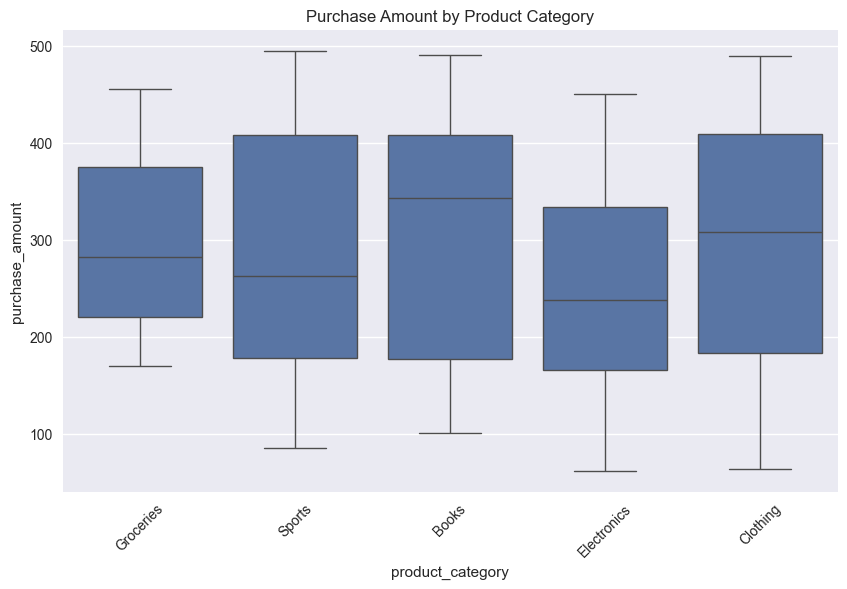

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_merged,
    x="product_category",
    y="purchase_amount"
)
plt.xticks(rotation=45)
plt.title("Purchase Amount by Product Category")
plt.show()

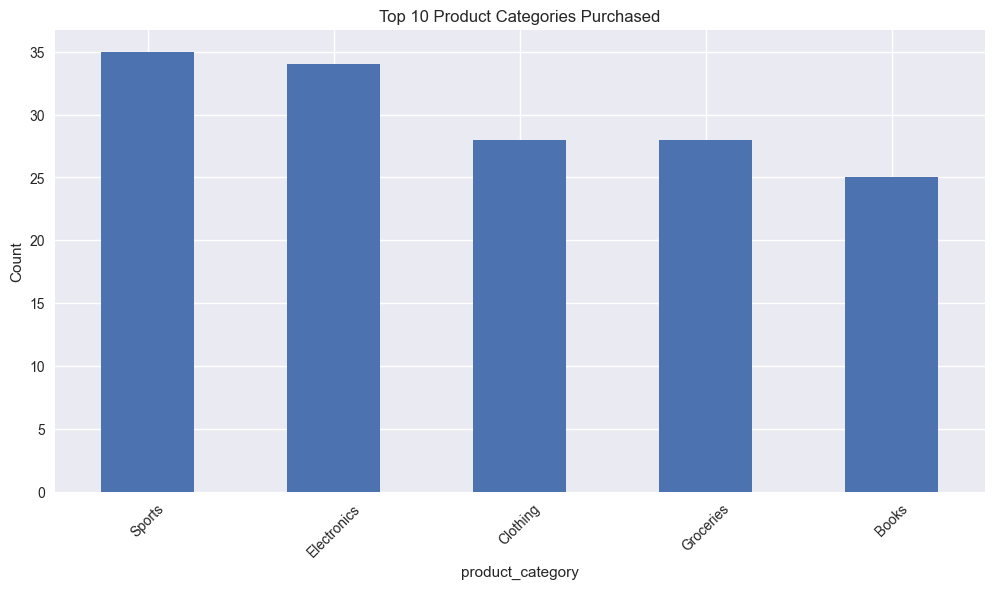

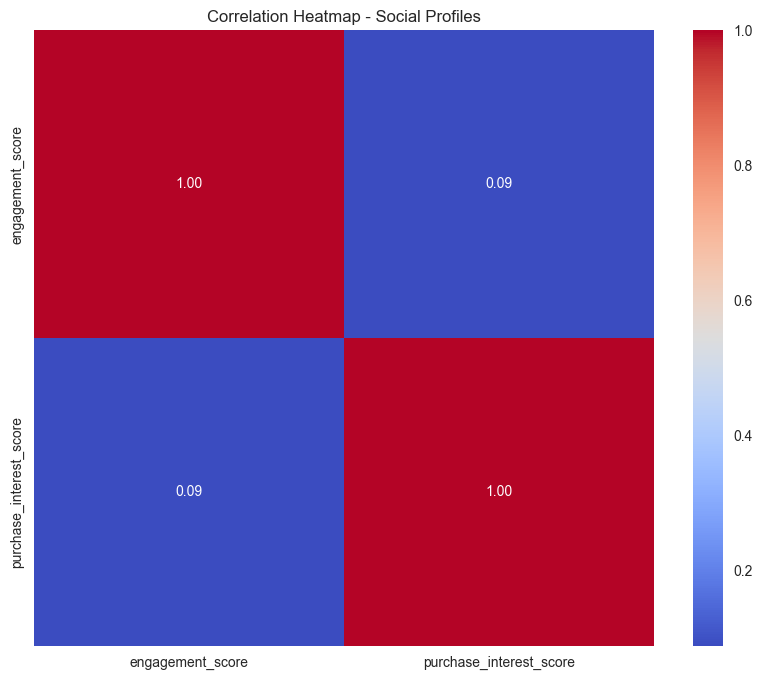

In [7]:
# =============================================================================
# Cell 3: Key EDA Plots 
# =============================================================================
# Plot 1: Age distribution 
if 'age' in profiles.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(profiles['age'], kde=True, bins=20)
    plt.title("Age Distribution of Customers")
    plt.show()

# Plot 2: Most common product categories 
if 'product_category' in transactions.columns:
    plt.figure(figsize=(12, 6))
    transactions['product_category'].value_counts().head(10).plot(kind='bar')
    plt.title("Top 10 Product Categories Purchased")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# Plot 3: Correlation heatmap 
numeric_cols = profiles.select_dtypes(include=np.number).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(profiles[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Heatmap - Social Profiles")
    plt.show()

## 8. Exploratory Data Analysis (EDA)

In [8]:
# =============================================================================
# Cell 4: FIXED MERGE LOGIC (WITH FULL DATA CLEANING)
# =============================================================================

print("=" * 50)
print("FIXED MERGE - Removing 'A' prefix from profiles")
print("=" * 50)

# Check for nulls
print("\n Checking for null values before merge:")
print(f"   Profiles nulls: {profiles.isnull().sum().sum()}")
print(f"   Transactions nulls: {transactions.isnull().sum().sum()}")

# Check for duplicates in ID columns
print(f"\ Checking for duplicates in ID columns:")
print(f"   Profiles duplicate IDs: {profiles['customer_id_new'].duplicated().sum()}")
print(f"   Transactions duplicate IDs: {transactions['customer_id_legacy'].duplicated().sum()}")

# Remove any rows with null IDs (if necessary)
profiles = profiles.dropna(subset=['customer_id_new'])
transactions = transactions.dropna(subset=['customer_id_legacy'])
# ---------------------------------------------

# Clean profiles IDs - remove the 'A' prefix
profiles['clean_id'] = profiles['customer_id_new'].astype(str).str.replace('A', '', regex=False)

# Transactions IDs are already clean
transactions['clean_id'] = transactions['customer_id_legacy'].astype(str)

# Check the overlap
common_ids = set(profiles['clean_id']) & set(transactions['clean_id'])
print(f"\n Found {len(common_ids)} matching customer IDs")
print(f"   Sample matches: {sorted(list(common_ids))[:10]}")

# --- ADD POST-MERGE VALIDATION ---
print("\n" + "=" * 50)
print("POST-MERGE VALIDATION")
print("=" * 50)
# ---------------------------------

# Perform the merge on the cleaned IDs
df_merged = pd.merge(
    profiles,
    transactions,
    left_on='clean_id',
    right_on='clean_id',
    how='inner',
    suffixes=('_profile', '_tx')
)

print(f"\n Merged shape: {df_merged.shape}")
print(f" Rows: {len(df_merged)} transactions")
print(f" Unique customers: {df_merged['clean_id'].nunique()}")

# Check for any nulls after merge
print(f"\n Null values after merge: {df_merged.isnull().sum().sum()}")

# Show merge efficiency
merge_efficiency = (len(df_merged) / (len(profiles) + len(transactions))) * 100
print(f" Merge efficiency: {merge_efficiency:.1f}% of total rows kept")
# ----------------------------------

# Save a backup
df_merged.to_csv('../data/processed/df_merged_fixed.csv', index=False)
print(f"\n Saved to ../data/processed/df_merged_fixed.csv")

# Show sample
print("\n First 5 rows of merged data:")
if len(df_merged) > 0:
    display_cols = []
    for col in ['customer_id_new', 'clean_id', 'transaction_id', 'purchase_amount']:
        if col in df_merged.columns:
            display_cols.append(col)
    print(df_merged[display_cols].head())

FIXED MERGE - Removing 'A' prefix from profiles

 Checking for null values before merge:
   Profiles nulls: 0
   Transactions nulls: 10
\ Checking for duplicates in ID columns:
   Profiles duplicate IDs: 71
   Transactions duplicate IDs: 75

 Found 61 matching customer IDs
   Sample matches: ['100', '101', '102', '103', '104', '105', '106', '107', '111', '113']

POST-MERGE VALIDATION

 Merged shape: (219, 14)
 Rows: 219 transactions
 Unique customers: 61

 Null values after merge: 19
 Merge efficiency: 71.8% of total rows kept

 Saved to ../data/processed/df_merged_fixed.csv

 First 5 rows of merged data:
  customer_id_new clean_id  transaction_id  purchase_amount
0            A190      190            1031              333
1            A190      190            1140              401
2            A150      150            1042              389
3            A150      150            1046              177
4            A162      162            1079              101


## 9. Feature Engineering

In [9]:
# =============================================================================
# Cell: Define merge key and target column 
# =============================================================================

print("=" * 50)
print("DEFINING MODEL VARIABLES")
print("=" * 50)

merge_key = 'customer_id_new'

print(f"Available columns in df_merged:")
for col in df_merged.columns:
    print(f"  - {col}")

# Find the target column 
target_col = None

# Look for product/category columns
category_cols = [col for col in df_merged.columns if 'category' in col.lower()]
product_cols = [col for col in df_merged.columns if 'product' in col.lower()]

print(f"\n Found category columns: {category_cols}")
print(f" Found product columns: {product_cols}")

# Choose the most likely target
if 'product_category' in df_merged.columns:
    target_col = 'product_category'
elif category_cols:
    target_col = category_cols[0]
elif product_cols:
    target_col = product_cols[0]
else:
    # If no obvious target, show first few columns for user to choose
    print("\n  No obvious target column found.")
    print("First 10 columns:", df_merged.columns[:10].tolist())
    target_col = input("Enter the name of the column you want to predict: ")

print(f"\n Using:")
print(f"   merge_key = '{merge_key}'")
print(f"   target_col = '{target_col}'")

# Check if the target column exists
if target_col in df_merged.columns:
    print(f"\n Target distribution:")
    print(df_merged[target_col].value_counts().head(10))
else:
    print(f"\n ERROR: '{target_col}' not found in dataframe!")

DEFINING MODEL VARIABLES
Available columns in df_merged:
  - customer_id_new
  - social_media_platform
  - engagement_score
  - purchase_interest_score
  - review_sentiment
  - customer_id_profile
  - clean_id
  - customer_id_legacy
  - transaction_id
  - purchase_amount
  - purchase_date
  - product_category
  - customer_rating
  - customer_id_tx

 Found category columns: ['product_category']
 Found product columns: ['product_category']

 Using:
   merge_key = 'customer_id_new'
   target_col = 'product_category'

 Target distribution:
product_category
Sports         60
Electronics    46
Books          41
Groceries      39
Clothing       33
Name: count, dtype: int64


## 11. Model Training & Evaluation

In [10]:
# =============================================================================
# Cell 5: Prepare Data for Modeling 
# =============================================================================

print("=" * 50)
print("PREPARING DATA FOR MODELING")
print("=" * 50)

# Define your key columns
merge_key = 'customer_id_new'  
target_col = 'product_category'  

# Select features (exclude ID columns and target)
id_cols = [merge_key, 'customer_id_legacy', 'customer_id_tx', 'transaction_id', 
           'customer_id_profile', 'clean_id', 'merge_key']
id_cols = [col for col in id_cols if col in df_merged.columns]

feature_cols = [col for col in df_merged.columns if col not in id_cols and col != target_col]
print(f" Total features: {len(feature_cols)}")

# Create feature matrix X and target vector y
X = df_merged[feature_cols].copy()
y = df_merged[target_col].copy()

# Handle categorical variables
cat_cols = X.select_dtypes(include=['object', 'str', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f"\n Column types:")
print(f"   Numeric: {len(num_cols)}")
print(f"   Categorical: {len(cat_cols)}")

# Encode categorical variables
if cat_cols:
    print("\n Encoding categorical variables...")
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    print(f"   After encoding: {X.shape}")

# Handle missing values
if X.isnull().any().any():
    print("\n  Filling missing values...")
    X = X.fillna(X.mean())

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\n Target classes: {le.classes_}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n Train/test split complete:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")

PREPARING DATA FOR MODELING
 Total features: 7

 Column types:
   Numeric: 4
   Categorical: 3

 Encoding categorical variables...
   After encoding: (219, 126)

  Filling missing values...

 Target classes: ['Books' 'Clothing' 'Electronics' 'Groceries' 'Sports']

 Train/test split complete:
   X_train: (175, 126)
   X_test: (44, 126)
   y_train: (175,)
   y_test: (44,)


In [11]:
# =============================================================================
# Cell 6: Train & Evaluate Model (try both RF and XGBoost)
# =============================================================================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.3f} | F1-weighted: {f1:.3f}")
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Save best model (e.g. XGBoost if better)
best_model = models["XGBoost"]  # or whichever performed best
best_model.save_model('../models/recommender_model.json')
print("Product recommender model saved.")


=== RandomForest ===
Accuracy: 0.659 | F1-weighted: 0.673
Classification Report:
               precision    recall  f1-score   support

       Books       1.00      0.62      0.77         8
    Clothing       1.00      0.57      0.73         7
 Electronics       0.50      0.44      0.47         9
   Groceries       1.00      0.75      0.86         8
      Sports       0.48      0.83      0.61        12

    accuracy                           0.66        44
   macro avg       0.80      0.64      0.69        44
weighted avg       0.75      0.66      0.67        44


=== XGBoost ===
Accuracy: 0.477 | F1-weighted: 0.480
Classification Report:
               precision    recall  f1-score   support

       Books       0.57      0.50      0.53         8
    Clothing       0.40      0.57      0.47         7
 Electronics       0.44      0.44      0.44         9
   Groceries       0.75      0.38      0.50         8
      Sports       0.43      0.50      0.46        12

    accuracy            

First 5 rows of merged data:
  customer_id_new social_media_platform  engagement_score  \
0            A190               Twitter                82   
1            A190               Twitter                82   
2            A150              Facebook                96   
3            A150              Facebook                96   
4            A162               Twitter                89   

   purchase_interest_score review_sentiment customer_id_profile clean_id  \
0                      4.8          Neutral                 190      190   
1                      4.8          Neutral                 190      190   
2                      1.6         Positive                 150      150   
3                      1.6         Positive                 150      150   
4                      2.6         Positive                 162      162   

   customer_id_legacy  transaction_id  purchase_amount purchase_date  \
0                 190            1031              333    2024-01-31   
1  

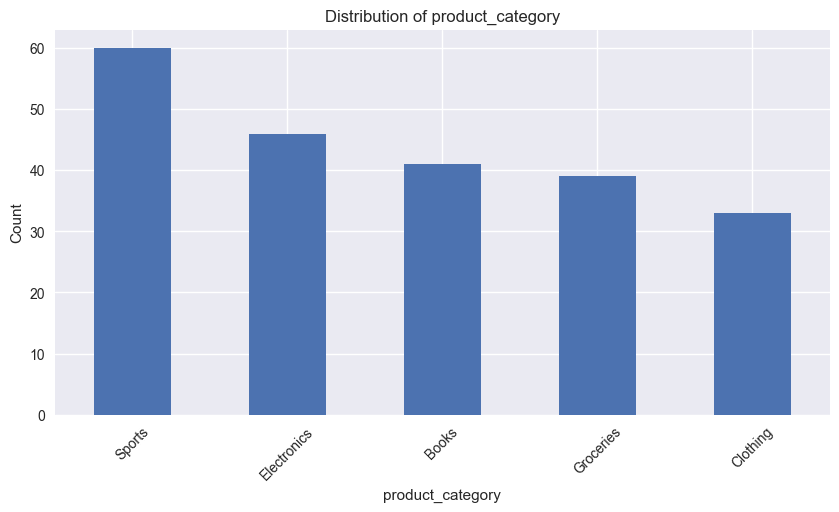

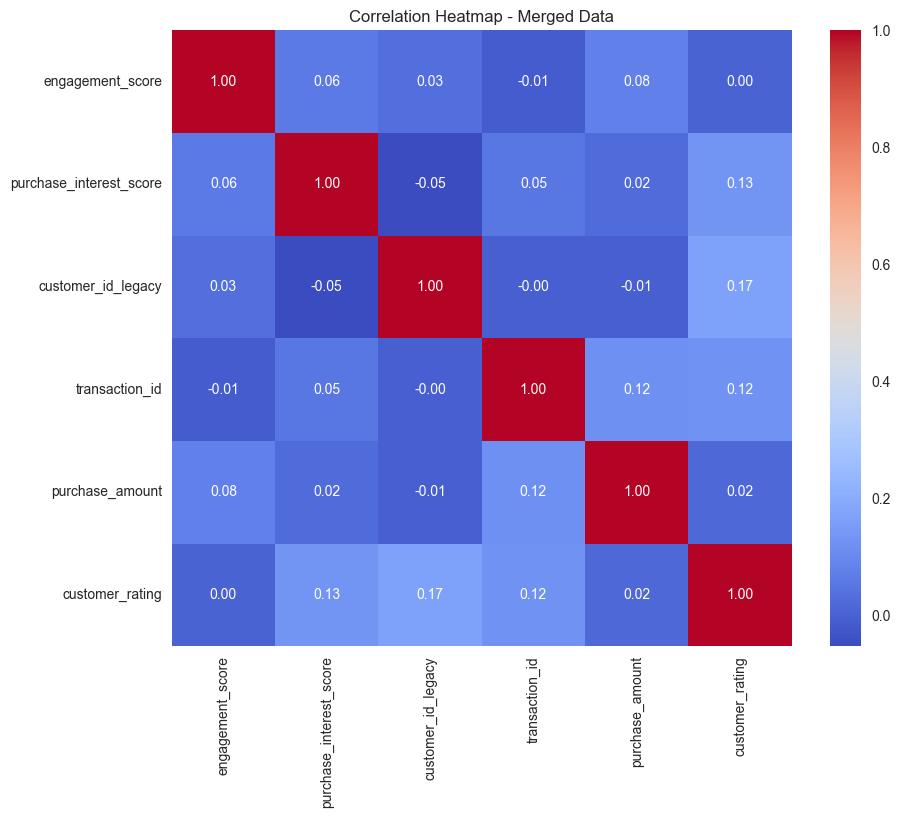

In [12]:
# =============================================================================
# Diagnostics & Visualization of Merged Data
# =============================================================================
# Show first samples of merged DataFrame
print("First 5 rows of merged data:")
print(df_merged.head())

# Check for missing values
print("\nMissing values per column:")
print(df_merged.isnull().sum())

# Visualize target column distribution (if not empty)
if not df_merged[target_col].empty:
    plt.figure(figsize=(10, 5))
    df_merged[target_col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {target_col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
else:
    print(f"No values found in target column '{target_col}' after merge.")

# Correlation heatmap for merged numeric columns
numeric_cols_merged = df_merged.select_dtypes(include=np.number).columns
if len(numeric_cols_merged) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_merged[numeric_cols_merged].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Heatmap - Merged Data")
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")